# Домашнее задание 1 (hw_1)

Потребуются следующие данные:

- [коллекция WikIR/en1k](https://zenodo.org/record/3565761/files/wikIR1k.zip)

- [список стоп-слов](https://gist.githubusercontent.com/sebleier/554280/raw/7e0e4a1ce04c2bb7bd41089c9821dbcf6d0c786c/NLTK's%2520list%2520of%2520english%2520stopwords)

- Л.Н. Толстой, "Война и мир":
  - [том 1](http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0040.shtml)
  - [том 2](http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0050.shtml)
  - [том 3](http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0060.shtml)
  - [том 4](http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0070.shtml)

- Ф.М. Достоевский, "Братья Карамазовы":
  - [часть 1](http://az.lib.ru/d/dostoewskij_f_m/text_0100.shtml)
  - [часть 2](http://az.lib.ru/d/dostoewskij_f_m/text_0110.shtml)
  - [часть 3](http://az.lib.ru/d/dostoewskij_f_m/text_0120.shtml)
  - [часть 4](http://az.lib.ru/d/dostoewskij_f_m/text_0130.shtml)

Коллекция WikIR загружается отдельно (более 100 МБ), остальные файлы находятся в
директории `data/`. Для работы с лемматизацией необходимо установить модель `spaCy`:

```bash
!python -m spacy download en_core_web_sm
```


## Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from nltk.stem.porter import PorterStemmer
import spacy
from transformers import BertTokenizer


documents = pd.read_csv('data/documents.csv')

# Токенизированные документы (коллекция уже предобработана)
tokenized_docs = [doc.split() for doc in documents['text_right']]

# Загрузка стоп-слов
with open('data/stopwords.txt', 'r') as f:
    stopwords = set(f.read().splitlines())

len(tokenized_docs), len(stopwords)

d:\GitHub\itmo-ir-search\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(369721, 127)

## Задача 1: Анализ текстовой коллекции (WikIR en1k)

### Базовые статистики коллекции

In [2]:
# 1. Количество документов
num_docs = len(tokenized_docs)

# 2. Размер коллекции (в словах)
total_words = sum(len(doc) for doc in tokenized_docs)

# 3. Средняя длина документа
avg_doc_len = total_words / num_docs if num_docs > 0 else 0

# Подсчет частот слов
all_words_counter = Counter(word for doc in tokenized_docs for word in doc)

# 4. Количество уникальных слов
unique_words = len(all_words_counter)

# 5. Средняя длина слова (с учетом частот)
avg_word_length = (
    sum(len(word) * count for word, count in all_words_counter.items()) / total_words
)

# 6. Средняя длина уникального слова
avg_unique_word_length = (
    sum(len(word) for word in all_words_counter.keys()) / unique_words
    if unique_words > 0
    else 0
)

print(f'1. Количество документов: {num_docs}')
print(f'2. Размер коллекции (слов): {total_words}')
print(f'3. Средняя длина документа: {avg_doc_len:.2f}')
print(f'4. Уникальных слов: {unique_words}')
print(f'5. Средняя длина слова: {avg_word_length:.2f}')
print(f'6. Средняя длина уникального слова: {avg_unique_word_length:.2f}')

1. Количество документов: 369721
2. Размер коллекции (слов): 73093729
3. Средняя длина документа: 197.70
4. Уникальных слов: 794568
5. Средняя длина слова: 4.80
6. Средняя длина уникального слова: 7.71


### Частотный словарь и стоп-слова

In [3]:
# Частотный список слов (по убыванию)
most_common = all_words_counter.most_common()

# Общее число вхождений стоп-слов
stopwords_occurrences = sum(count for word, count in most_common if word in stopwords)
print(f'Количество вхождений стоп-слов: {stopwords_occurrences}')

# Топ-30 слов
top_30_words = [word for word, _ in most_common[:30]]

# Проверка: входят ли все топ-30 слов в стоп-лист
top_30_in_stopwords = [word in stopwords for word in top_30_words]

print(f'Все ли топ-30 слов — стоп-слова? {all(top_30_in_stopwords)}')
print('Топ-30 слов:', top_30_words)

# Слова из топ-30, отсутствующие в стоп-листе
missing_from_stopwords = [word for word in top_30_words if word not in stopwords]
print('Слова из топ-30 вне стоп-листа:', missing_from_stopwords)

Количество вхождений стоп-слов: 29387785
Все ли топ-30 слов — стоп-слова? False
Топ-30 слов: ['the', 'of', 'in', 'and', 'a', 'to', 'was', 'he', 'is', 'as', 'for', 'on', 'with', 'by', 's', 'at', 'his', 'from', 'it', 'that', 'an', 'which', 'first', 'are', 'were', 'has', 'also', 'she', 'after', 'its']
Слова из топ-30 вне стоп-листа: ['first', 'also']


### Законы Ципфа и Хипса

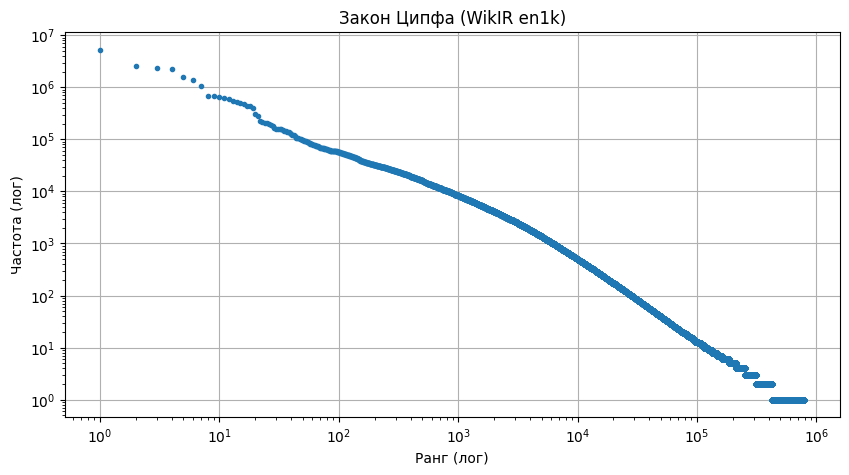

In [4]:
# График закона Ципфа
ranks = np.arange(1, len(most_common) + 1)
frequencies = [count for _, count in most_common]

plt.figure(figsize=(10, 5))
plt.loglog(ranks, frequencies, marker='.', linestyle='none')
plt.title('Закон Ципфа (WikIR en1k)')
plt.xlabel('Ранг (лог)')
plt.ylabel('Частота (лог)')
plt.grid(True)
plt.show()

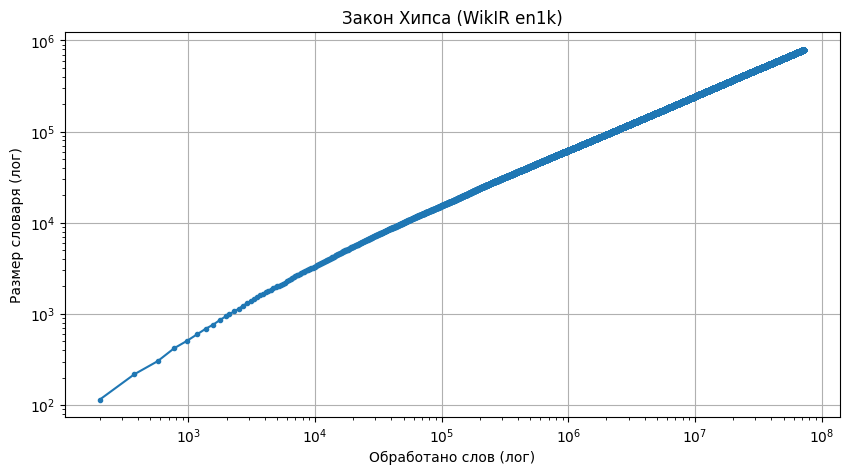

In [5]:
# График закона Хипса
vocab = set()
vocab_sizes = []
tokens_processed = []

current_tokens = 0

# Считаем по документам (для ускорения)
for doc in tokenized_docs:
    current_tokens += len(doc)
    vocab.update(doc)
    tokens_processed.append(current_tokens)
    vocab_sizes.append(len(vocab))

plt.figure(figsize=(10, 5))
plt.loglog(tokens_processed, vocab_sizes, marker='.', linestyle='-')
plt.title('Закон Хипса (WikIR en1k)')
plt.xlabel('Обработано слов (лог)')
plt.ylabel('Размер словаря (лог)')
plt.grid(True)
plt.show()

## Частотный список биграмм

In [6]:
# Подсчет биграмм
bigrams_counter = Counter()

for doc in tokenized_docs:
    if len(doc) < 2:
        continue
    bigrams = [(doc[i], doc[i + 1]) for i in range(len(doc) - 1)]
    bigrams_counter.update(bigrams)

print(f'Количество уникальных биграмм: {len(bigrams_counter)}')

Количество уникальных биграмм: 12993004


In [7]:
# Топ-30 биграмм
top_bigrams = bigrams_counter.most_common(30)

print('Топ-30 биграмм:')
for bg, count in top_bigrams:
    print(f'{bg}: {count}')

Топ-30 биграмм:
('of', 'the'): 768320
('in', 'the'): 546863
('to', 'the'): 256451
('at', 'the'): 201351
('and', 'the'): 170394
('on', 'the'): 169708
('he', 'was'): 163554
('as', 'a'): 163073
('for', 'the'): 159502
('by', 'the'): 130810
('with', 'the'): 120118
('from', 'the'): 115219
('the', 'first'): 104264
('it', 'was'): 101387
('as', 'the'): 96915
('it', 'is'): 95880
('is', 'a'): 82161
('was', 'a'): 78342
('in', 'a'): 76786
('one', 'of'): 70278
('was', 'the'): 69881
('of', 'a'): 69345
('with', 'a'): 63880
('is', 'the'): 63672
('to', 'be'): 62139
('and', 'was'): 58478
('during', 'the'): 56159
('and', 'a'): 56121
('part', 'of'): 54180
('the', 'united'): 49922


## Морфологическая обработка

In [8]:
# 1. Стемминг (Porter Stemmer)
stemmer = PorterStemmer()

# Используем подвыборку для ускорения
sample_docs = documents[:5000]
sample_tokenized = tokenized_docs[:5000]

stemmed_docs = [[stemmer.stem(w) for w in doc] for doc in sample_tokenized]

# 2. Лемматизация (spaCy)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

lemmatized_docs = []
for doc in nlp.pipe(sample_docs['text_right'], batch_size=50):
    lemmatized_docs.append(
        [token.lemma_.lower() for token in doc if not token.is_space]
    )

# 3. Токенизация BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

bert_tokenized_docs = [tokenizer.tokenize(doc) for doc in sample_docs['text_right']]


# 4. Сравнение статистик


def get_stats(docs_list):
    total_tokens = sum(len(doc) for doc in docs_list)
    unique_tokens = len(set(word for doc in docs_list for word in doc))
    return total_tokens, unique_tokens


stats_orig = get_stats(sample_tokenized)
stats_stem = get_stats(stemmed_docs)
stats_lemm = get_stats(lemmatized_docs)
stats_bert = get_stats(bert_tokenized_docs)

print('             | Токенов всего | Уникальных токенов')
print(f'Оригинал     | {stats_orig[0]:<13} | {stats_orig[1]}')
print(f'Стемминг     | {stats_stem[0]:<13} | {stats_stem[1]}')
print(f'Лемматизация | {stats_lemm[0]:<13} | {stats_lemm[1]}')
print(f'BERT         | {stats_bert[0]:<13} | {stats_bert[1]}')

             | Токенов всего | Уникальных токенов
Оригинал     | 988313        | 61757
Стемминг     | 988313        | 48506
Лемматизация | 988472        | 54275
BERT         | 1098605       | 25702


## Дополнительное задание 1: Анализ словарей авторов

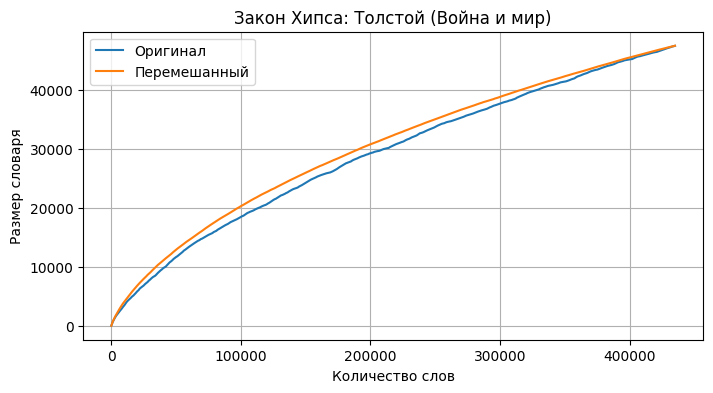

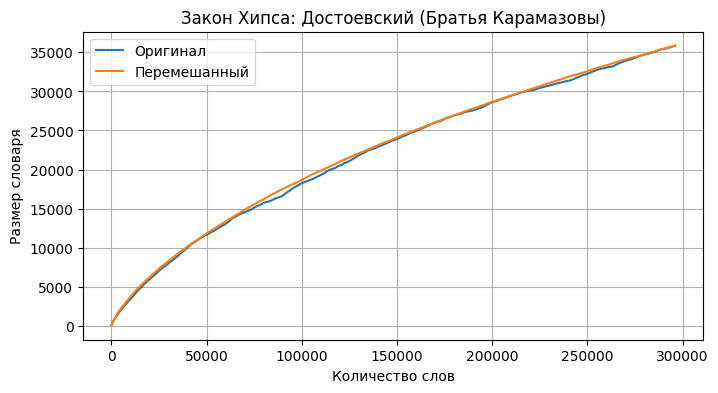

In [9]:
# Загрузка текстов
with open('data/tolstoy.txt', 'r', encoding='utf-8') as f:
    tolstoy_text = f.read()

with open('data/dostoevsky.txt', 'r', encoding='utf-8') as f:
    dostoevsky_text = f.read()


# Очистка и токенизация
def clean_tokenize(text):
    text = text.lower()
    words = re.findall(r'[а-яё]+', text)
    return words


tolstoy_words = clean_tokenize(tolstoy_text)
dostoevsky_words = clean_tokenize(dostoevsky_text)


# Закон Хипса (оригинал vs перемешанный текст)
def plot_heaps_shuffled(words, author_name):
    shuffled_words = words.copy()
    np.random.shuffle(shuffled_words)

    def get_heaps_curve(word_list):
        v = set()
        v_sizes = []
        t_processed = []

        for i, w in enumerate(word_list):
            v.add(w)
            if i % 1000 == 0:
                v_sizes.append(len(v))
                t_processed.append(i)

        return t_processed, v_sizes

    t1, v1 = get_heaps_curve(words)
    t2, v2 = get_heaps_curve(shuffled_words)

    plt.figure(figsize=(8, 4))
    plt.plot(t1, v1, label='Оригинал')
    plt.plot(t2, v2, label='Перемешанный')
    plt.title(f'Закон Хипса: {author_name}')
    plt.xlabel('Количество слов')
    plt.ylabel('Размер словаря')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_heaps_shuffled(tolstoy_words, 'Толстой (Война и мир)')
plot_heaps_shuffled(dostoevsky_words, 'Достоевский (Братья Карамазовы)')

In [10]:
# Характерные слова
t_counter = Counter(tolstoy_words)
d_counter = Counter(dostoevsky_words)

vocab_common = set(w for w, c in t_counter.items() if c > 10) & set(
    w for w, c in d_counter.items() if c > 10
)

tolstoy_total = len(tolstoy_words)
dostoevsky_total = len(dostoevsky_words)

word_scores = []

for w in vocab_common:
    pf_t = t_counter[w] / tolstoy_total
    pf_d = d_counter[w] / dostoevsky_total
    ratio = pf_t / pf_d
    word_scores.append((w, ratio, pf_t, pf_d))

word_scores.sort(key=lambda x: x[1], reverse=True)

print('Характерные слова Толстого:', [w[0] for w in word_scores[:10]])
print('Характерные слова Достоевского:', [w[0] for w in word_scores[-10:]])

Характерные слова Толстого: ['андрей', 'всё', 'сказала', 'марья', 'офицер', 'отвечал', 'генерал', 'улыбаясь', 'перед', 'выражение']
Характерные слова Достоевского: ['пред', 'г', 'вовсе', 'чрезвычайно', 'затем', 'придет', 'например', 'убил', 'ибо', 'пусть']


## Дополнительное задание 2: Детекция сгенерированных текстов (CoAT)

Загрузка датасета CoAT...
[Human (5000)] слов: 61567, уникальных: 18447, отношение: 0.2996
[AI (5000)] слов: 60999, уникальных: 16671, отношение: 0.2733


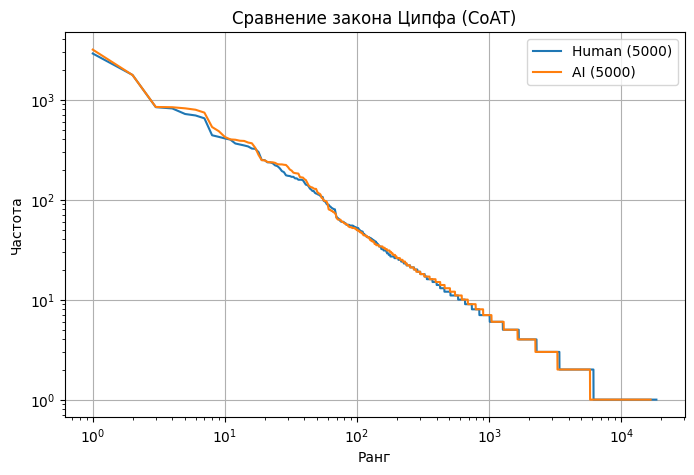

In [11]:
print('Загрузка датасета CoAT...')

df_coat = pd.read_parquet(
    'hf://datasets/RussianNLP/coat/authorship/train-00000-of-00001.parquet'
)

human_texts = df_coat[df_coat['label'] == 'Human']['text'].tolist()
ai_texts = df_coat[df_coat['label'] != 'Human']['text'].tolist()


def analyze_corpus(texts, label):
    words = clean_tokenize(' '.join(texts))
    counter = Counter(words)

    total = len(words)
    unique = len(counter)

    print(
        f'[{label}] слов: {total}, уникальных: {unique}, отношение: {unique / total if total > 0 else 0:.4f}'
    )

    ranks = np.arange(1, len(counter) + 1)
    freqs = sorted(counter.values(), reverse=True)

    plt.loglog(ranks, freqs, label=label)


plt.figure(figsize=(8, 5))

analyze_corpus(human_texts[:5000], 'Human (5000)')
analyze_corpus(ai_texts[:5000], 'AI (5000)')

plt.title('Сравнение закона Ципфа (CoAT)')
plt.xlabel('Ранг')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()